In [1]:
from IPython import display
display.clear_output()

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [13]:
def load_dataset(root_dir):
    train_dir = os.path.join(root_dir, 'train')
    valid_dir = os.path.join(root_dir, 'valid')

    # Load training data
    train_images, train_annotations = load_data(train_dir)

    # Load validation data
    valid_images, valid_annotations = load_data(valid_dir)

    return train_images, train_annotations, valid_images, valid_annotations

In [14]:
def load_data(data_dir):
    image_paths = []
    annotation_paths = []

    # Collect image and annotation file paths
    for filename in os.listdir(data_dir):
        if filename.endswith('.jpg') or filename.endswith('.png'):
            image_paths.append(os.path.join(data_dir, filename))
            annotation_paths.append(os.path.join(data_dir, filename.replace('.jpg', '.txt').replace('.png', '.txt')))

    # Load images
    images = [cv2.imread(img_path) for img_path in image_paths]

    # Load annotations
    annotations = [load_annotations(ann_path) for ann_path in annotation_paths]

    return images, annotations

In [15]:
def load_annotations(annotation_path):
    with open(annotation_path, 'r') as file:
        lines = file.readlines()
        # Assuming YOLO format: class, x_center, y_center, width, height
        annotations = [list(map(float, line.strip().split())) for line in lines]

    return np.array(annotations)


root_directory = ''
train_images, train_annotations, valid_images, valid_annotations = load_dataset(root_directory)

In [16]:
train_directory = './train'
files_in_directory = os.listdir(train_directory)
print(files_in_directory)

['images', 'labels', 'labels.cache']


In [17]:
valid_directory = './valid'
files_in_directory = os.listdir(valid_directory)
print(files_in_directory)

['images', 'labels', 'labels.cache']


In [18]:
def load_sample_data(data_dir):
    image_dir = os.path.join(data_dir, 'images')
    label_dir = os.path.join(data_dir, 'labels')

    image_paths, label_paths = [], []

    # Collect image and label file paths
    for filename in os.listdir(image_dir):
        if filename.endswith('.jpg'):
            image_paths.append(os.path.join(image_dir, filename))
            label_paths.append(os.path.join(label_dir, filename.replace('.jpg', '.txt')))

    return image_paths, label_paths

In [19]:
def load_annotations(annotation_path):
    with open(annotation_path, 'r') as file:
        lines = file.readlines()
        # Assuming YOLO format: class, x_center, y_center, width, height
        annotations = [list(map(float, line.strip().split())) for line in lines]

    return annotations

image_paths, annotation_paths = load_sample_data(train_directory)

In [20]:
def count_files(directory):
    image_dir = os.path.join(directory, 'images')
    label_dir = os.path.join(directory, 'labels')

    image_count = len([f for f in os.listdir(image_dir) if f.endswith('.jpg')])
    label_count = len([f for f in os.listdir(label_dir) if f.endswith('.txt')])

    return image_count, label_count

image_count, label_count = count_files(train_directory)

print(f"Number of images in the training set: {image_count}")
print(f"Number of labels in the training set: {label_count}")

Number of images in the training set: 4317
Number of labels in the training set: 4317


In [21]:
# Print labels for the first 10 samples
for i in range(min(10, len(annotation_paths))):
    sample_annotations = load_annotations(annotation_paths[i])
    print(f"Labels for {annotation_paths[i]}:")
    print(sample_annotations)
    print("------------------------")

Labels for ./train\labels\-10-_jpg.rf.b7c032d4993e9154bd6e5a49c8630171.txt:
[[3.0, 0.50625, 0.41640625, 0.553125, 0.353125]]
------------------------
Labels for ./train\labels\-23-_jpg.rf.4bde6ff326f5275f2b87eb7737d93f43.txt:
[[3.0, 0.496875, 0.41015625, 0.69375, 0.371875]]
------------------------
Labels for ./train\labels\-24-_jpg.rf.654314d9394a4823daa2c5248a47ab56.txt:
[[3.0, 0.55625, 0.34140625, 0.5125, 0.3296875]]
------------------------
Labels for ./train\labels\-52-_jpg.rf.cadc098cfeda1f6419d8bee774763996.txt:
[[3.0, 0.55234375, 0.41015625, 0.5109375, 0.340625]]
------------------------
Labels for ./train\labels\-69-_jpg.rf.4d06eda3fffec64fae49829f69e4ca7c.txt:
[[3.0, 0.5484375, 0.35703125, 0.5078125, 0.3265625]]
------------------------
Labels for ./train\labels\-82-_jpg.rf.998ff2603ba0377daedcfa4c55576ae6.txt:
[[3.0, 0.59609375, 0.43984375, 0.5578125, 0.353125]]
------------------------
Labels for ./train\labels\-87-_jpg.rf.87136331810d141593173091bde9e48f.txt:
[[3.0, 0.5671

In [22]:
image_paths, annotation_paths = load_sample_data(valid_directory)


for i in range(min(10, len(annotation_paths))):
    sample_annotations = load_annotations(annotation_paths[i])
    print(f"Labels for {annotation_paths[i]}:")
    print(sample_annotations)
    print("------------------------")

Labels for ./valid\labels\-102-_jpg.rf.06ad9fb656b1b847d3bde26a4d77d4dd.txt:
[[3.0, 0.5375, 0.46015625, 0.515625, 0.2875]]
------------------------
Labels for ./valid\labels\-19-_jpg.rf.deadd01c25146228cafbc9033b0262e6.txt:
[[3.0, 0.56484375, 0.4, 0.390625, 0.2140625]]
------------------------
Labels for ./valid\labels\-28-_jpg.rf.8a0212c60c2a2f4bbedb06c76d9cb515.txt:
[[3.0, 0.55390625, 0.48203125, 0.5421875, 0.3234375]]
------------------------
Labels for ./valid\labels\-85-_jpg.rf.4569f18ac61d5b3f089b1126d35881be.txt:
[[3.0, 0.57109375, 0.48671875, 0.5375, 0.3265625]]
------------------------
Labels for ./valid\labels\0000481806_jpg.rf.fe528cfd460e0d1b39b1f623938cde60.txt:
[[3.0, 0.89921875, 0.63984375, 0.2015625, 0.1515625]]
------------------------
Labels for ./valid\labels\013_10_jpeg_jpg.rf.b2b6db3750845caab6484f6bd84e2c61.txt:
[[1.0, 0.7296875, 0.2984375, 0.09453125, 0.09609375], [1.0, 0.453125, 0.68828125, 0.3859375, 0.43125], [2.0, 0.4203125, 0.37109375, 0.1375, 0.09609375], [

In [23]:
def load_sample_data(data_dir):
    image_dir = os.path.join(data_dir, 'images')
    label_dir = os.path.join(data_dir, 'labels')

    image_paths, label_paths = [], []

    # Collect image and label file paths
    for filename in os.listdir(image_dir):
        if filename.endswith('.jpg'):
            image_paths.append(os.path.join(image_dir, filename))
            label_paths.append(os.path.join(label_dir, filename.replace('.jpg', '.txt')))

    return image_paths, label_paths

def load_annotations(annotation_path):
    with open(annotation_path, 'r') as file:
        lines = file.readlines()
        # Assuming YOLO format: class, x_center, y_center, width, height
        annotations = [list(map(float, line.strip().split())) for line in lines]

    return annotations

In [24]:
def display_sample(image_path, annotations):
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    fig, ax = plt.subplots(1)
    ax.imshow(image)

    for annotation in annotations:
        class_label, x_center, y_center, width, height = annotation
        x, y, w, h = x_center, y_center, width, height

        # Convert YOLO coordinates to bounding box coordinates
        x *= image.shape[1]
        y *= image.shape[0]
        w *= image.shape[1]
        h *= image.shape[0]

        # Calculate top-left corner coordinates
        x -= w / 2
        y -= h / 2

        # Create a rectangle patch
        rect = patches.Rectangle((x, y), w, h, linewidth=1, edgecolor='r', facecolor='none')
        ax.add_patch(rect)

        # Display class label
        plt.text(x, y, f'{int(class_label)}', color='r')

    plt.show()


image_paths, annotation_paths = load_sample_data(train_directory)

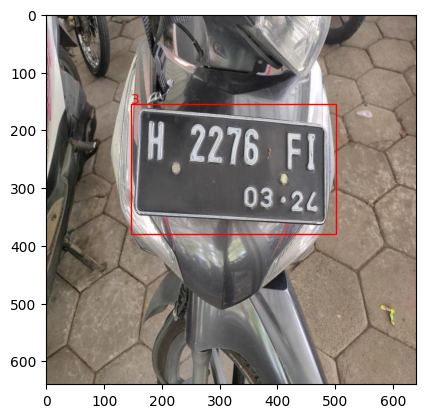

Annotations plotted for ./train\images\-10-_jpg.rf.b7c032d4993e9154bd6e5a49c8630171.jpg


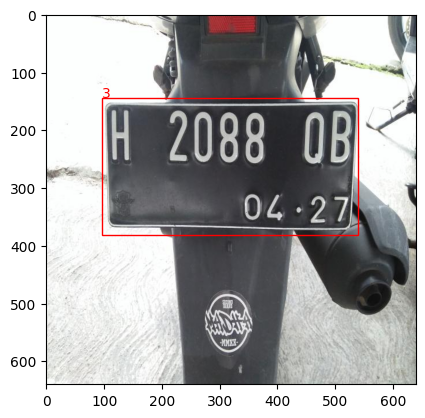

Annotations plotted for ./train\images\-23-_jpg.rf.4bde6ff326f5275f2b87eb7737d93f43.jpg


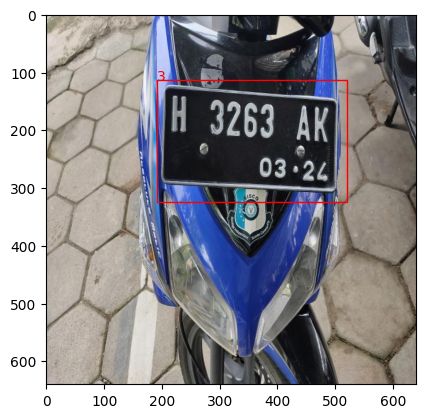

Annotations plotted for ./train\images\-24-_jpg.rf.654314d9394a4823daa2c5248a47ab56.jpg


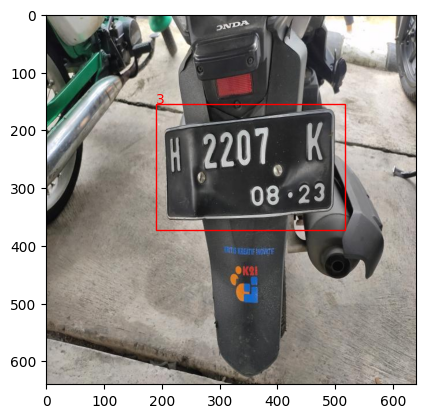

Annotations plotted for ./train\images\-52-_jpg.rf.cadc098cfeda1f6419d8bee774763996.jpg


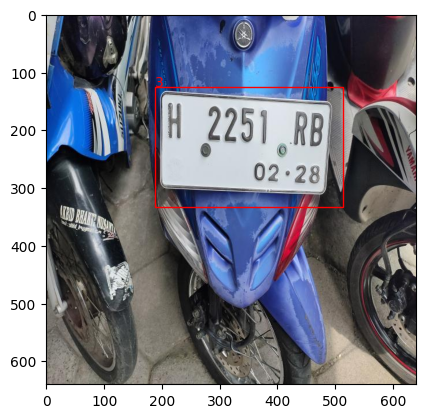

Annotations plotted for ./train\images\-69-_jpg.rf.4d06eda3fffec64fae49829f69e4ca7c.jpg


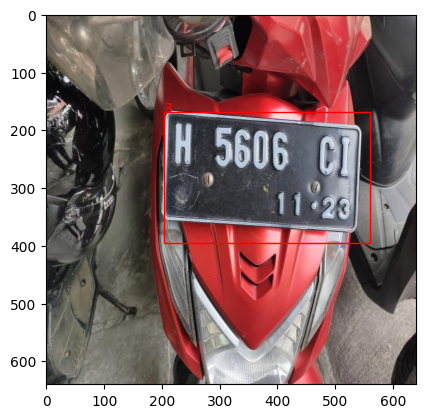

Annotations plotted for ./train\images\-82-_jpg.rf.998ff2603ba0377daedcfa4c55576ae6.jpg


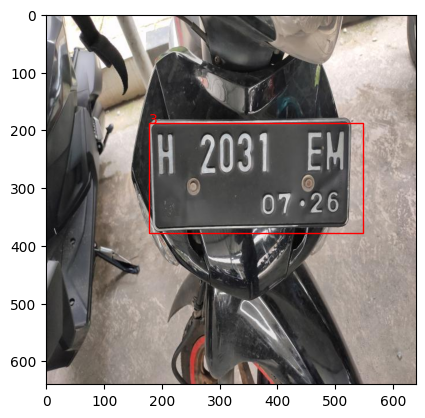

Annotations plotted for ./train\images\-87-_jpg.rf.87136331810d141593173091bde9e48f.jpg


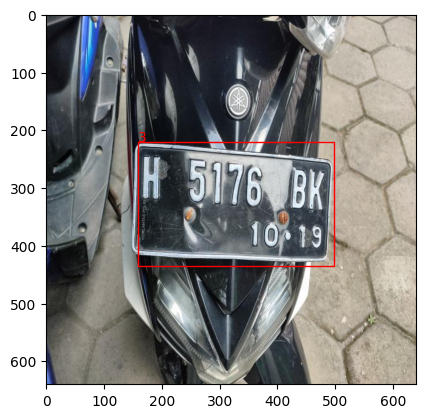

Annotations plotted for ./train\images\-91-_jpg.rf.c02ff4db064f26a9627242d79beae9bb.jpg


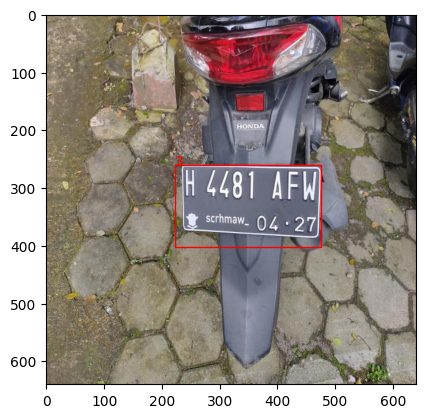

Annotations plotted for ./train\images\-94-_jpg.rf.675668d78801d9bd5e2fbe65c863c276.jpg


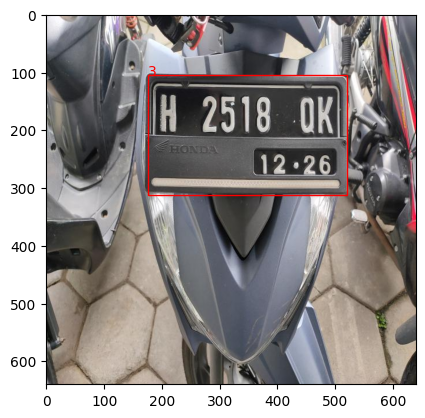

Annotations plotted for ./train\images\-97-_jpg.rf.36ac40c00a3661e38dbd82fdb29ca36f.jpg


In [25]:
# Display and plot annotations for the first 10 images
for i in range(min(10, len(image_paths))):
    try:
        sample_image_path = image_paths[i]
        sample_annotations = load_annotations(annotation_paths[i])
        display_sample(sample_image_path, sample_annotations)
        print(f"Annotations plotted for {sample_image_path}")
    except:
        pass

In [15]:
from ultralytics import YOLO
from IPython.display import display, Image

In [ ]:
model=YOLO("yolo12n.pt")

In [17]:
results=model.train(data=r"C:\Users\Home\Downloads\helmet\one\data.yaml",epochs=3,imgsz=640)


New https://pypi.org/project/ultralytics/8.3.70 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.68  Python-3.10.9 torch-2.5.1+cpu CPU (Intel Core(TM) i5-6600 3.30GHz)
engine\trainer: task=detect, mode=train, model=yolo11n.pt, data=C:\Users\Home\Downloads\helmet\one\data.yaml, epochs=3, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, sho

train: Scanning C:\Users\Home\Downloads\helmet\one\train\labels... 4317 images, 0 backgrounds, 0 corrupt: 100%|██████████| 4317/4317 [00:26<00:00, 164.24it/s]


train: New cache created: C:\Users\Home\Downloads\helmet\one\train\labels.cache
WARNING  Box and segment counts should be equal, but got len(segments) = 2371, len(boxes) = 26426. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


val: Scanning C:\Users\Home\Downloads\helmet\one\valid\labels... 1218 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1218/1218 [00:05<00:00, 205.60it/s]


val: New cache created: C:\Users\Home\Downloads\helmet\one\valid\labels.cache
WARNING  Box and segment counts should be equal, but got len(segments) = 835, len(boxes) = 7423. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
Plotting labels to runs\detect\train\labels.jpg... 
optimizer: 'optimizer=auto' found, ignoring 'lr0=0.01' and 'momentum=0.937' and determining best 'optimizer', 'lr0' and 'momentum' automatically... 
optimizer: AdamW(lr=0.00125, momentum=0.9) with parameter groups 81 weight(decay=0.0), 88 weight(decay=0.0005), 87 bias(decay=0.0)
TensorBoard: model graph visualization added 
Image sizes 640 train, 640 val
Using 0 dataloader workers
Logging results to runs\detect\train
Starting training for 3 epochs...

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


...

                   all       1218       7423      0.618      0.575      0.568      0.267

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size


        3/3         0G      1.577      1.459      1.387         91        640: 100%|██████████| 270/270 [26:21<00:00,  5.86s/it]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 39/39 [02:50<00:00,  4.37s/it]


                   all       1218       7423      0.664      0.632      0.634      0.328

3 epochs completed in 1.679 hours.
Optimizer stripped from runs\detect\train\weights\last.pt, 5.5MB
Optimizer stripped from runs\detect\train\weights\best.pt, 5.5MB

Validating runs\detect\train\weights\best.pt...
Ultralytics 8.3.68  Python-3.10.9 torch-2.5.1+cpu CPU (Intel Core(TM) i5-6600 3.30GHz)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 39/39 [02:12<00:00,  3.39s/it]


                   all       1218       7423      0.664      0.631      0.634      0.328
                     0        848       2383       0.75      0.569      0.638      0.322
                     1       1123       2463      0.637       0.76      0.733      0.427
                     2        478        817      0.518      0.572       0.49      0.262
                     3        703       1760       0.75      0.624      0.676      0.301
Speed: 1.8ms preprocess, 95.4ms inference, 0.0ms loss, 4.2ms postprocess per image
Results saved to runs\detect\train


In [18]:
results=model.val()

Ultralytics 8.3.68  Python-3.10.9 torch-2.5.1+cpu CPU (Intel Core(TM) i5-6600 3.30GHz)
YOLO11n summary (fused): 238 layers, 2,582,932 parameters, 0 gradients, 6.3 GFLOPs


val: Scanning C:\Users\Home\Downloads\helmet\one\valid\labels.cache... 1218 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1218/1218 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 835, len(boxes) = 7423. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 77/77 [02:03<00:00,  1.60s/it]


                   all       1218       7423      0.664      0.631      0.634      0.328
                     0        848       2383       0.75      0.569      0.638      0.322
                     1       1123       2463      0.637       0.76      0.733      0.427
                     2        478        817      0.518      0.572       0.49      0.262
                     3        703       1760       0.75      0.624      0.676      0.301
Speed: 1.7ms preprocess, 88.6ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to runs\detect\train2


In [2]:
from ipywidgets import FileUpload, Output
from IPython.display import display, Image
from ultralytics import YOLO
import cv2
import numpy as np

# Load the YOLO model
model = YOLO("D:/2024 projects/helmet/runs/detect/train/weights/best.pt")

# Create file upload widget
file_upload = FileUpload(accept='image/*', multiple=False)  # Only accept image files
output = Output()

def on_upload_change(change):
    # Clear previous output
    output.clear_output()
    
    # Retrieve the uploaded file
    if isinstance(file_upload.value, dict):  # Check if value is a dict (older versions)
        uploaded_file = list(file_upload.value.values())[0]
        content = uploaded_file['content']
        filename = uploaded_file['metadata']['name']
    elif isinstance(file_upload.value, tuple):  # Check for tuple (newer versions)
        uploaded_file = file_upload.value[0]
        content = uploaded_file['content']
        filename = uploaded_file['name']
    else:
        with output:
            print("Unrecognized file_upload structure!")
        return
    
    # Save the uploaded file temporarily
    temp_path = f"./{filename}"
    with open(temp_path, 'wb') as f:
        f.write(content)
    
    # Load the image with OpenCV
    image = cv2.imdecode(np.frombuffer(content, np.uint8), cv2.IMREAD_COLOR)
    
    # Perform YOLO prediction
    results = model.predict(source=image, show=False)  # Disable display in this function
    
    # Draw bounding boxes on the image
    for result in results:
        for box in result.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])  # Bounding box coordinates
            class_id = int(box.cls[0])  # Class ID
            class_name = model.names[class_id]  # Get class name from ID
            confidence = box.conf[0]  # Confidence score
            
            # Draw the bounding box and label
            cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)  # Green box
            label = f"{class_name} ({confidence:.2f})"
            cv2.putText(image, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    # Display detected classes and the image with bounding boxes
    with output:
        print("Detected Classes:")
        for result in results:
            for box in result.boxes:
                class_id = int(box.cls[0])  # Class ID
                class_name = model.names[class_id]  # Get class name from ID
                print(class_name)
        
        # Convert image to JPEG for display
        _, encoded_img = cv2.imencode('.jpg', image)
        display(Image(data=encoded_img.tobytes(), format='jpg'))

# Attach event listener to the file upload widget
file_upload.observe(on_upload_change, names='value')

# Display widgets
display(file_upload, output)


FileUpload(value=(), accept='image/*', description='Upload')

Output()